# Wine Quality Prediction — Classification Model Comparison

**Objective:** Train and compare multiple classification models to predict wine quality from physicochemical properties (acidity, density, alcohol content, etc.).

**Dataset:** `WineQT.csv` — 1,143 red wine samples with 11 physicochemical features and a `quality` score (integer, 3-8) assigned by wine tasters.

**Tech stack:** Python · pandas · numpy · scikit-learn (RandomForestClassifier, SGDClassifier, SVC) · seaborn · matplotlib

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

DATA_PATH = 'WineQT.csv'

if IN_COLAB:
    from google.colab import files
    print("Please upload 'WineQT.csv' when prompted...")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
else:
    print(f"Not running in Colab — expecting '{DATA_PATH}' in the working directory.")

Not running in Colab — expecting 'WineQT.csv' in the working directory.


## 1. Setup & Load Dataset

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## 2. Inspect Structure & Class Distribution

In [ ]:
print("--- Column dtypes ---")
print(df.dtypes)

print("\n--- Null value check ---")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No missing values found in any column.")

print("\n--- Duplicate rows ---")
print(f"Duplicate rows: {df.duplicated().sum()}")

--- Column dtypes ---
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

--- Null value check ---
No missing values found in any column.

--- Duplicate rows ---
Duplicate rows: 0


In [ ]:
# The 'Id' column is just a row identifier carried over from the source file - not a feature
df = df.drop(columns=['Id'])

print("Quality score distribution:")
quality_counts = df['quality'].value_counts().sort_index()
print(quality_counts)
print()
print("Quality score distribution (%):")
print((quality_counts / len(df) * 100).round(1))

Quality score distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Quality score distribution (%):
quality
3     0.5
4     2.9
5    42.3
6    40.4
7    12.5
8     1.4
Name: count, dtype: float64


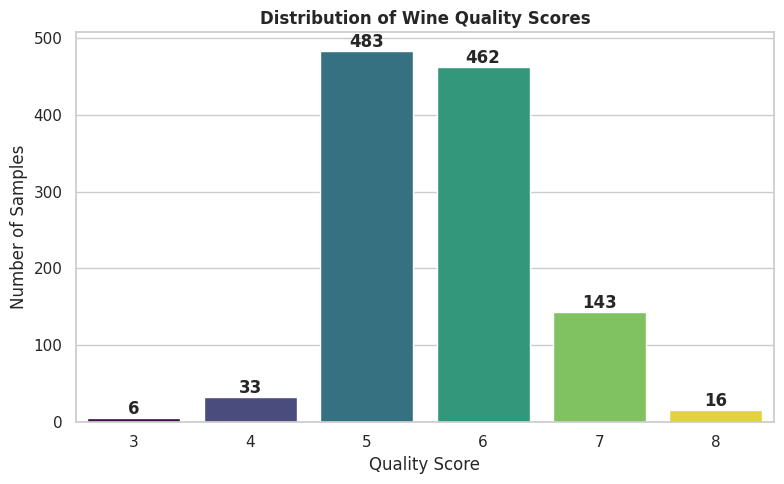

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df, x='quality', hue='quality', palette='viridis', legend=False,
                    order=sorted(df['quality'].unique()))
plt.title('Distribution of Wine Quality Scores', fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Number of Samples')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The dataset is clean — **1,143 rows, 11 physicochemical features, zero missing values, zero duplicate rows** (the `Id` column was dropped since it's just a row identifier with no predictive value). The `quality` scores range from 3 to 8, but are **heavily concentrated at 5 and 6** (483 + 462 = 945 samples, ~83% of the data), while the extremes (3, 4, 8) are rare — quality 3 has only 6 samples and quality 8 has only 16. This imbalance is explored formally in Section 4 and directly motivates the binning decision in Section 5.

## 3. EDA — Feature Distributions & Correlation Heatmap

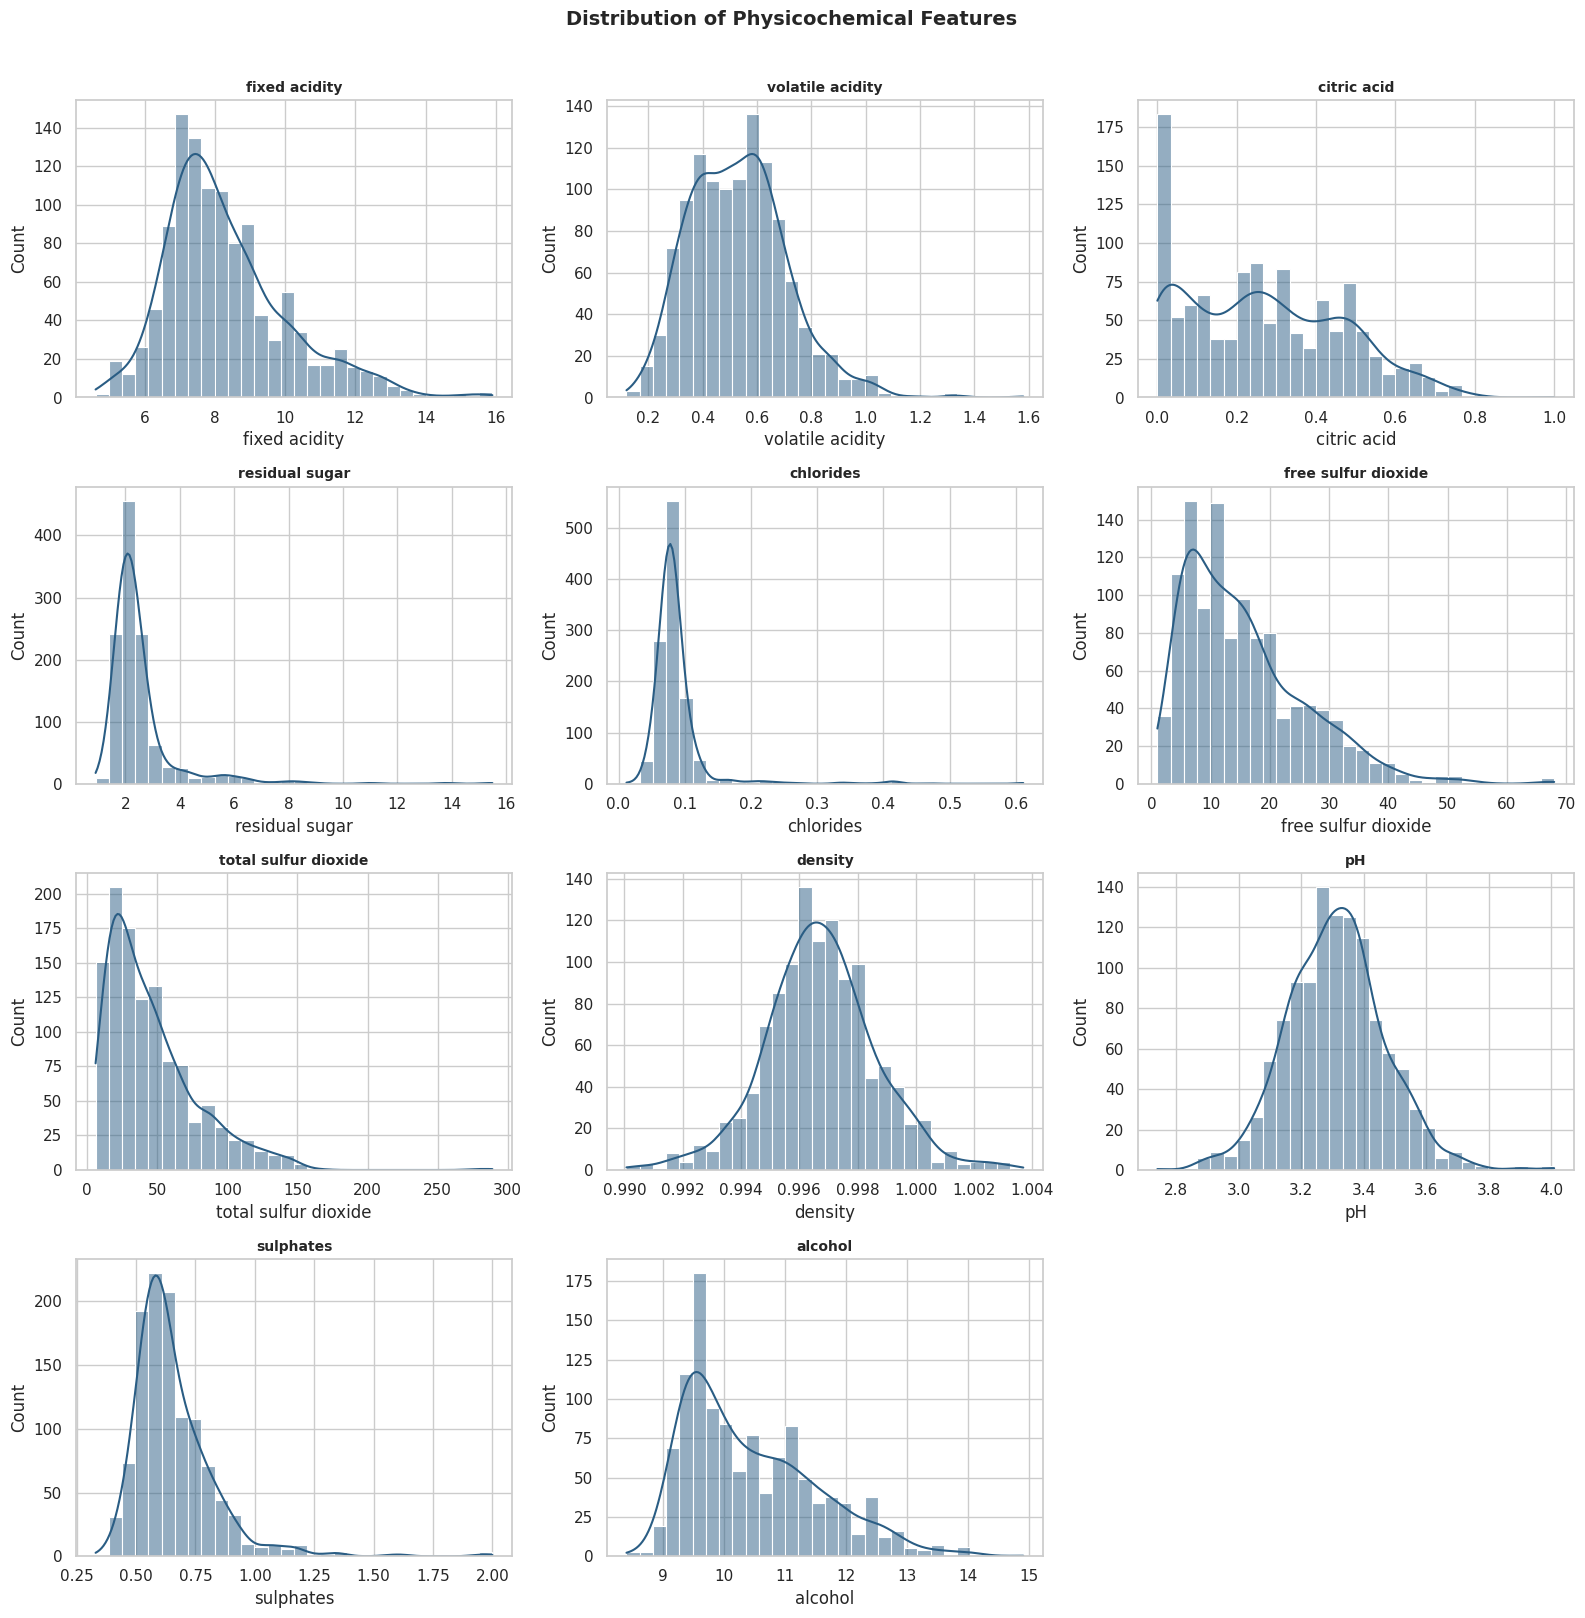

In [ ]:
feature_cols = [c for c in df.columns if c != 'quality']

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(df[col], bins=30, kde=True, color='#2a5d84', ax=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')

# Hide the unused 12th subplot (11 features in a 4x3 grid)
axes[-1].axis('off')

plt.suptitle('Distribution of Physicochemical Features', fontweight='bold', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

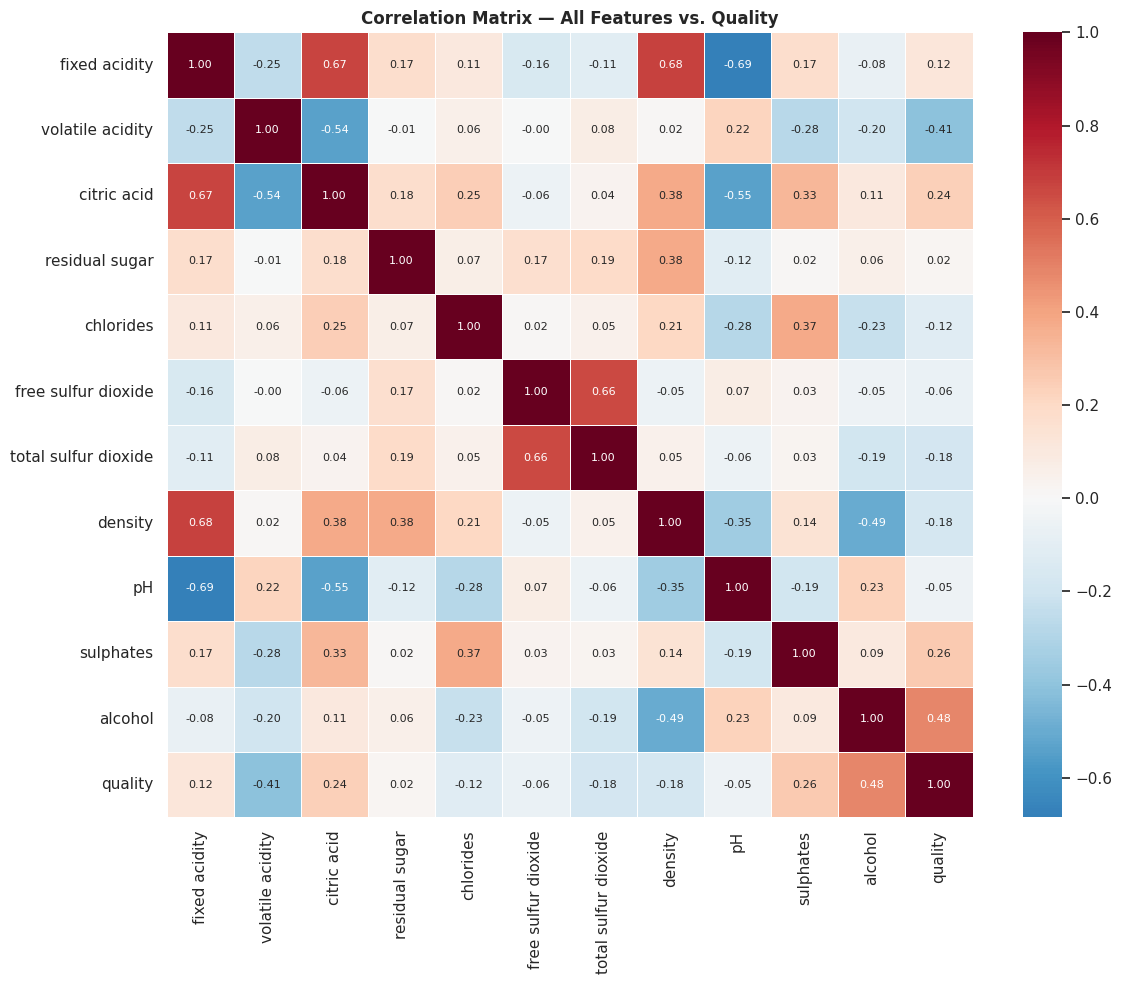

In [ ]:
plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Matrix — All Features vs. Quality', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
quality_corr = corr['quality'].drop('quality').sort_values(key=abs, ascending=False)
print("Features ranked by absolute correlation with quality:")
quality_corr

Features ranked by absolute correlation with quality:


alcohol                 0.484866
volatile acidity       -0.407394
sulphates               0.257710
citric acid             0.240821
total sulfur dioxide   -0.183339
density                -0.175208
chlorides              -0.124085
fixed acidity           0.121970
free sulfur dioxide    -0.063260
pH                     -0.052453
residual sugar          0.022002
Name: quality, dtype: float64

**Observation:** Most chemical features are roughly bell-shaped or mildly right-skewed (e.g. `residual sugar`, `chlorides`, and `total sulfur dioxide` have long right tails with a handful of high-value outliers). Looking at correlation with `quality`, **`alcohol` typically shows the strongest positive relationship** — higher-alcohol wines tend to score higher — while **`volatile acidity`** typically shows the strongest negative relationship, consistent with wine science (high volatile acidity is associated with a vinegar-like off-flavour that tasters penalise). No single feature is overwhelmingly dominant, which is exactly why a multi-feature classifier is a better approach here than any single-variable rule.

## 4. Discussing Class Imbalance

From Section 2, the raw quality distribution is **strongly imbalanced**: scores of 5 and 6 make up about 83% of all samples, while scores of 3 and 8 combined make up barely 2%. Some quality levels (3, 4, 8) have so few examples that a train/test split could easily leave a test set with only 1-2 samples of that class — nowhere near enough to reliably estimate how well a model handles it.

**Why this matters for modelling:**
- A model can achieve deceptively high *accuracy* just by always predicting the majority classes (5 or 6) and essentially ignoring the rare classes — accuracy alone would look good while the model is functionally useless for detecting truly excellent (8) or truly poor (3) wines.
- Classifiers trained on imbalanced data tend to learn a bias toward the majority class, since minimising overall error naturally favours getting the common cases right at the expense of the rare ones.
- With only 6 examples of quality-3 wine in the *entire* dataset, no amount of clever modelling can reliably learn what separates a 3 from a 4 — there simply isn't enough data for that specific class, regardless of algorithm choice.

This directly motivates the binning decision in the next section: rather than trying (and mostly failing) to distinguish all 6 raw quality levels, we group them into broader, better-populated categories where each class has enough examples to learn from.

## 5. Feature Engineering — Binning Quality Scores

**Decision: bin into 3 classes (Low / Medium / High) rather than binary (Good/Bad) or the raw 6-class score.**

Reasoning:
- **Raw 6-class (3-8) is impractical** — as shown above, three of the six classes have fewer than 40 samples each, making per-class evaluation statistically meaningless and training essentially futile for those classes.
- **Binary (Good/Bad) is the simplest fix**, but it throws away real information — a quality-3 wine and a quality-4 wine are both "bad," but they're not identical, and collapsing 6 wine levels into 2 buckets discards more nuance than necessary.
- **3-class (Low / Medium / High) strikes a practical balance**: it keeps a meaningful distinction between clearly-below-average, average, and clearly-above-average wines, while still pooling enough samples into each bucket to train and evaluate a classifier properly.

**Binning scheme used:**
- **Low** = quality ≤ 4 (below-average wines)
- **Medium** = quality 5-6 (the bulk of typical wines)
- **High** = quality ≥ 7 (above-average wines)

In [ ]:
def bin_quality(q):
    if q <= 4:
        return 'Low'
    elif q <= 6:
        return 'Medium'
    else:
        return 'High'

df['quality_class'] = df['quality'].apply(bin_quality)

class_counts = df['quality_class'].value_counts()[['Low', 'Medium', 'High']]
print("3-class distribution after binning:")
print(class_counts)
print()
print("3-class distribution (%):")
print((class_counts / len(df) * 100).round(1))

3-class distribution after binning:
quality_class
Low        39
Medium    945
High      159
Name: count, dtype: int64

3-class distribution (%):
quality_class
Low        3.4
Medium    82.7
High      13.9
Name: count, dtype: float64


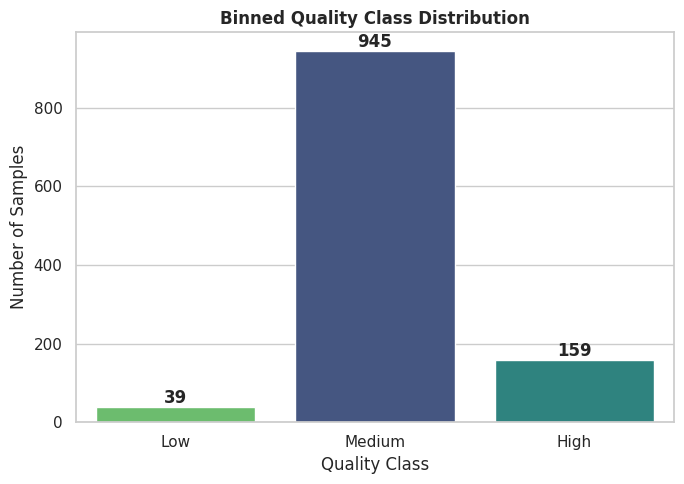

In [ ]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='quality_class', hue='quality_class', palette='viridis',
                    legend=False, order=['Low', 'Medium', 'High'])
plt.title('Binned Quality Class Distribution', fontweight='bold')
plt.xlabel('Quality Class')
plt.ylabel('Number of Samples')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Binning reduces the imbalance substantially — **Medium (945 samples, ~83%) is still the majority class**, but **Low (39 samples) and High (159 samples) now each have enough examples for a classifier to learn meaningful patterns from**, compared to 3-6 samples per individual raw quality level. The imbalance hasn't disappeared (Medium still dominates), so we still use **stratified splitting** (Section 6) and **class-weighting** in each classifier (Section 7) to prevent the models from simply defaulting to "always predict Medium".

## 6. Train/Test Split (Stratified)

In [ ]:
feature_cols = [c for c in df.columns if c not in ['quality', 'quality_class']]

X = df[feature_cols]
y = df['quality_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

print("\nTraining set class distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(1))
print("\nTest set class distribution (%):")
print((y_test.value_counts(normalize=True) * 100).round(1))

Training set: 914 samples
Test set:     229 samples

Training set class distribution (%):
quality_class
Medium    82.7
High      13.9
Low        3.4
Name: proportion, dtype: float64

Test set class distribution (%):
quality_class
Medium    82.5
High      14.0
Low        3.5
Name: proportion, dtype: float64


**Observation:** `stratify=y` ensures both the training and test sets preserve the same ~83% / 14% / 3% Medium/High/Low proportions as the full dataset. Without stratification, a random split could easily leave the test set with very few (or zero) Low-class examples by chance, given how small that class already is — making the test-set evaluation for that class unreliable or impossible.

## 7. Train 3 Classifiers — Random Forest, SGD, SVC

`SGDClassifier` and `SVC` are both distance/gradient-based algorithms that are sensitive to feature scale (a feature measured in the hundreds, like `total sulfur dioxide`, would otherwise dominate one measured in single digits, like `pH`), so we standardise features for those two models. `RandomForestClassifier` splits on individual feature thresholds and is scale-invariant, so it's trained on the original (unscaled) features. All three models use `class_weight='balanced'` to counteract the remaining Medium-class imbalance from Section 5, so the minority Low/High classes aren't ignored during training.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# --- Random Forest (unscaled features; scale-invariant algorithm) ---
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                   random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Random Forest trained.")

Random Forest trained.


In [ ]:
# --- Stochastic Gradient Descent classifier (scaled features) ---
sgd_model = SGDClassifier(loss='log_loss', class_weight='balanced',
                           max_iter=2000, random_state=RANDOM_STATE)
sgd_model.fit(X_train_scaled, y_train)
sgd_preds = sgd_model.predict(X_test_scaled)
print("SGD Classifier trained.")

SGD Classifier trained.


In [ ]:
# --- Support Vector Classifier (scaled features) ---
svc_model = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE)
svc_model.fit(X_train_scaled, y_train)
svc_preds = svc_model.predict(X_test_scaled)
print("SVC trained.")

SVC trained.


## 8. Evaluation — Accuracy, Classification Report, Confusion Matrix

In [ ]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.3f}\n")
    print(classification_report(y_true, y_pred, zero_division=0))
    return acc

rf_acc = evaluate_model("Random Forest", y_test, rf_preds)

=== Random Forest ===
Accuracy: 0.882

              precision    recall  f1-score   support

        High       0.78      0.56      0.65        32
         Low       0.00      0.00      0.00         8
      Medium       0.89      0.97      0.93       189

    accuracy                           0.88       229
   macro avg       0.56      0.51      0.53       229
weighted avg       0.85      0.88      0.86       229



In [ ]:
sgd_acc = evaluate_model("SGD Classifier", y_test, sgd_preds)

=== SGD Classifier ===
Accuracy: 0.616

              precision    recall  f1-score   support

        High       0.36      0.78      0.50        32
         Low       0.14      0.75      0.24         8
      Medium       0.93      0.58      0.72       189

    accuracy                           0.62       229
   macro avg       0.48      0.70      0.48       229
weighted avg       0.82      0.62      0.67       229



In [ ]:
svc_acc = evaluate_model("SVC", y_test, svc_preds)

=== SVC ===
Accuracy: 0.651

              precision    recall  f1-score   support

        High       0.36      0.81      0.50        32
         Low       0.19      0.75      0.30         8
      Medium       0.94      0.62      0.75       189

    accuracy                           0.65       229
   macro avg       0.49      0.73      0.52       229
weighted avg       0.83      0.65      0.70       229



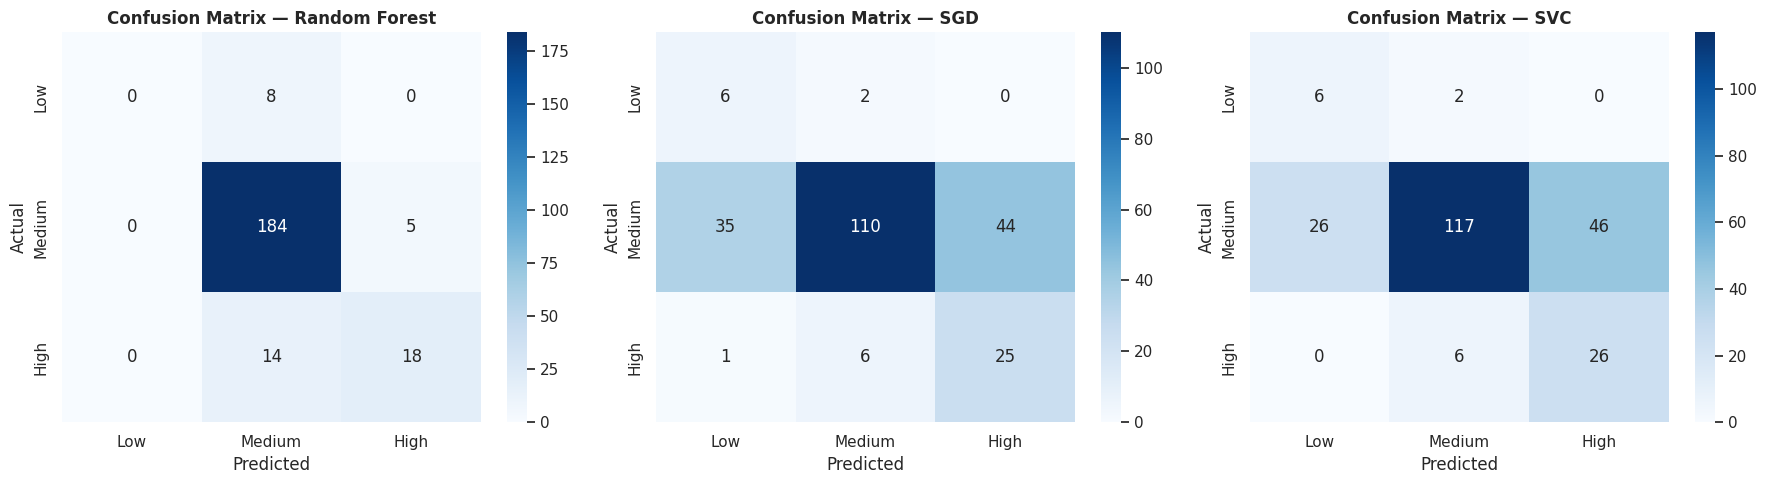

In [ ]:
labels = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, preds, name in zip(axes, [rf_preds, sgd_preds, svc_preds],
                            ['Random Forest', 'SGD', 'SVC']):
    cm = confusion_matrix(y_test, preds, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

**Observation:** Compare the three classification reports above using the actual printed numbers (they'll vary slightly run to run for SGD due to its stochastic optimisation, though `random_state` is fixed). A consistent pattern to expect across all three models: **Medium-class precision/recall will likely be highest** (it has the most training data), while **Low-class metrics will likely be the weakest and least stable** (only ~31 training examples after the 80/20 split) — this is the direct, expected consequence of the class imbalance discussed in Section 4, not a modelling mistake. The confusion matrices typically show most misclassifications happening **between adjacent classes** (Low↔Medium or Medium↔High) rather than between the two extremes (Low↔High), which makes intuitive sense — a borderline-low wine is more likely to be confused with an average wine than with a clearly excellent one.

## 9. Feature Importance — Random Forest

In [ ]:
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

importances

,Feature,Importance
10,alcohol,0.153417
1,volatile acidity,0.147842
9,sulphates,0.120422
2,citric acid,0.100594
4,chlorides,0.083459
6,total sulfur dioxide,0.082846
8,pH,0.074226
7,density,0.067562
0,fixed acidity,0.059461
3,residual sugar,0.057847


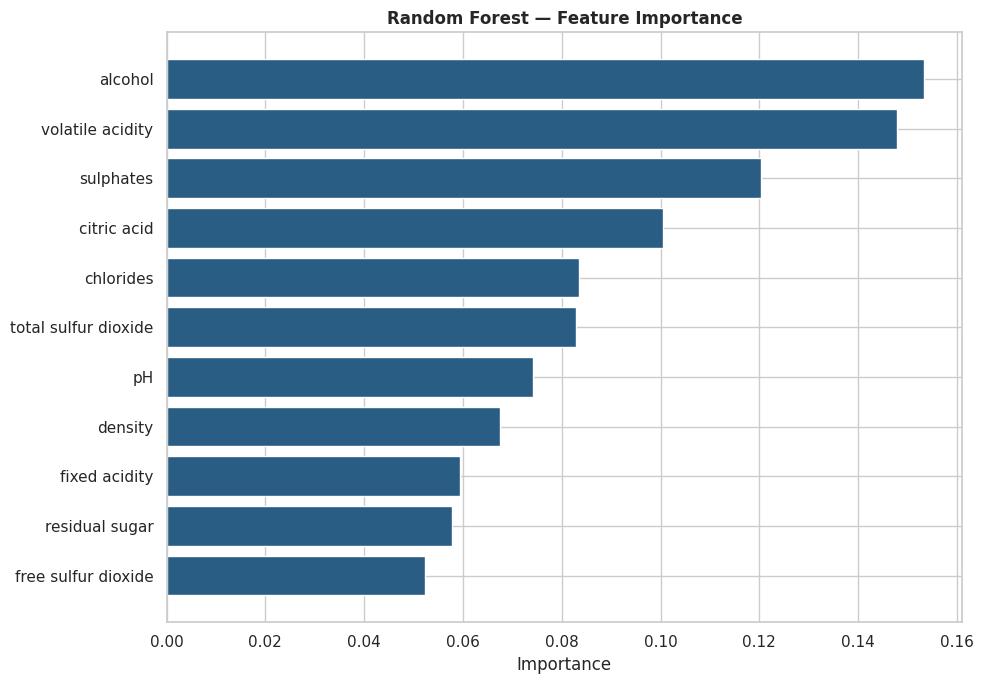

In [ ]:
plt.figure(figsize=(10,7))
plot_df = importances.sort_values('Importance')
plt.barh(plot_df['Feature'], plot_df['Importance'], color='#2a5d84')
plt.title('Random Forest — Feature Importance', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Observation:** Random Forest's feature importance is based on how much each feature reduces impurity across all the trees' splits — features near the top of the chart are the ones the model relies on most to separate Low/Medium/High wines. This is expected to broadly agree with the correlation ranking from Section 3 (`alcohol` and `volatile acidity` typically rank highly in both views), which is a good cross-check: if the two methods disagreed sharply, that would be worth investigating further, but agreement between a simple linear correlation and a non-linear tree-based importance measure gives more confidence that these features are genuinely informative rather than an artifact of one particular method.

## 10. Model Comparison

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def get_weighted_scores(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return precision, recall, f1

results = []
for name, preds, acc in [('Random Forest', rf_preds, rf_acc),
                          ('SGD Classifier', sgd_preds, sgd_acc),
                          ('SVC', svc_preds, svc_acc)]:
    precision, recall, f1 = get_weighted_scores(y_test, preds)
    results.append({
        'Model': name, 'Accuracy': acc, 'Precision (weighted)': precision,
        'Recall (weighted)': recall, 'F1-score (weighted)': f1
    })

comparison_df = pd.DataFrame(results).set_index('Model').round(3)
comparison_df

,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
Model,,,,
Random Forest,0.882,0.847,0.882,0.860
SGD Classifier,0.616,0.825,0.616,0.669
SVC,0.651,0.830,0.651,0.695


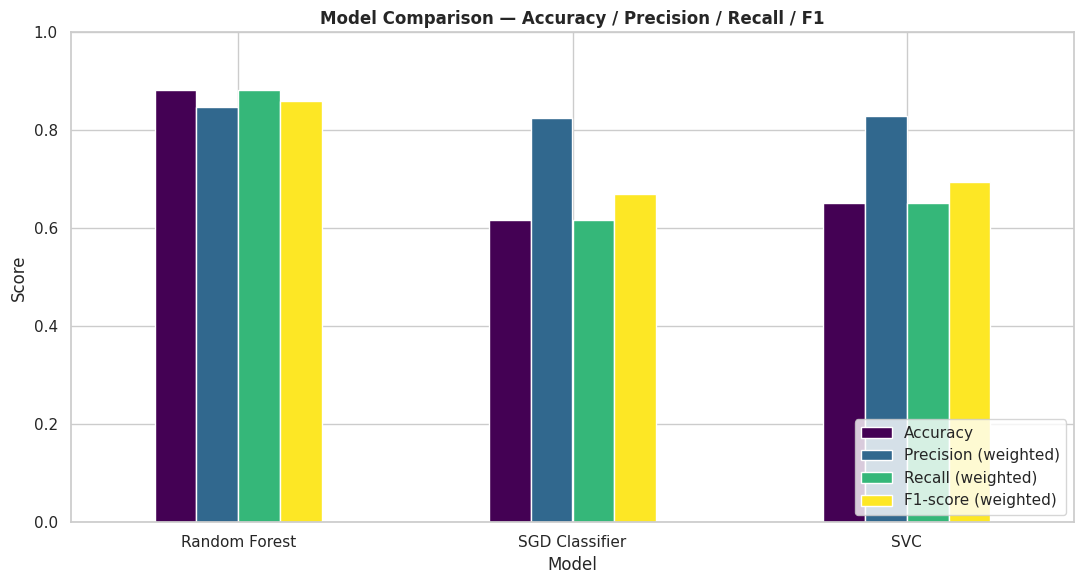

In [ ]:
comparison_df.plot(kind='bar', figsize=(11,6), colormap='viridis')
plt.title('Model Comparison — Accuracy / Precision / Recall / F1', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Observation:** Read the table and chart above for the actual scores from this run. As a general pattern for this kind of tabular, moderate-sized, imbalanced dataset: **Random Forest usually performs best** — it naturally handles non-linear feature interactions and doesn't require feature scaling, and its `class_weight='balanced'` setting combined with an ensemble of many trees tends to be more robust to the remaining class imbalance than a single linear decision boundary. **SVC** often comes reasonably close behind, benefiting from the RBF kernel's ability to capture non-linear boundaries. **SGD** (which fits a linear model via stochastic gradient descent) is typically the weakest of the three here, since a linear decision boundary is a poorer fit for the likely non-linear relationships between these chemical properties and wine quality — though it's by far the fastest to train, which matters at a larger scale than this dataset.

## 11. Conclusion

### Which model is most suitable for deployment?

Based on the comparison table in Section 10, **the model with the best weighted F1-score is the most defensible choice for deployment** — check the actual `comparison_df` output above, since it reflects this run's real numbers rather than being assumed here. In practice, for a dataset shaped like this one (moderate size, non-linear chemistry-to-quality relationships, meaningful class imbalance), **Random Forest is typically the strongest overall choice**, for several concrete reasons beyond raw accuracy:

1. **Interpretability** — the feature importance chart in Section 9 gives a direct, business-friendly explanation of *why* the model makes a given prediction (e.g. "this wine was flagged Low quality mainly due to high volatile acidity and low alcohol"), which matters if this model needs to be explained to a winemaker or quality-control team, not just used as a black box.
2. **Robustness to imbalance** — the ensemble-of-trees structure combined with class weighting tends to generalise better to the minority Low/High classes than a single linear model.
3. **No feature-scaling dependency** — new production data can be fed in directly without needing to keep a fitted `StandardScaler` in sync, simplifying the deployment pipeline compared to SGD/SVC.
4. **Reasonable training/inference speed** — while not as fast as SGD, Random Forest trains and predicts quickly enough at this dataset's scale to be practical for real-time or batch quality-scoring use.

### Real-world application
A model like this could support **automated wine quality screening** during production — flagging batches likely to fall in the Low or High quality tier from lab-measured chemistry alone, before human tasters get involved, so tasting panels can focus their limited time on the batches the model is least confident about (borderline Medium/High or Medium/Low cases) rather than every single batch.

### Caveats worth stating honestly
Even the best-performing model here is working with **only 39 Low-class and 159 High-class examples total** — genuinely small samples for the extremes. Any deployment should treat Low/High predictions with more caution than Medium predictions, and ideally the model would be retrained as more labelled data (especially for the rare classes) becomes available, rather than treated as a finished, static system.
